# TP étudiant — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [12]:
!pip install gymnasium
!pip install "gymnasium[toy-text]"
!pip install minigrid

print("Décommentez les installations si nécessaire.")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Décommentez les installations si nécessaire.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [14]:
# TODO
# Créer l'environnement Taxi-v3
env = gym.make("Taxi-v3")
# Afficher action_space, observation_space, spec et unwrapped
print("Action space :", env.action_space)
print("Observation space :", env.observation_space)
print("Spec :", env.spec)
print("Unwrapped :", env.unwrapped)

Action space : Discrete(6)
Observation space : Discrete(500)
Spec : EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Unwrapped : <TaxiEnv<Taxi-v3>>


**Réponse attendue :** décrivez brièvement ce que représente Taxi-v3 et pourquoi cet environnement est utile pour commencer.

Taxi-v3 est un environnement de reinforcement learning où un taxi doit récupérer un passager à un emplacement donné et le déposer à une destination spécifique dans une grille.

Cet environnement est utile pour commencer car :

- il est simple et discret (états et actions limités),
- il permet de comprendre les bases du RL (récompenses, transitions),
- il introduit les notions de stratégie et d’exploration.

## 2. Premier épisode avec actions aléatoires

In [ ]:
# TODO
# Exécuter un épisode aléatoire complet
obs, info = env.reset(seed=0)
episode_reward = 0.0
step_count = 0

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward
    step_count += 1

print("Nombre d'étapes :", step_count)
print("Récompense cumulée :", episode_reward)
print("Cause d'arrêt :", "terminated" if terminated else "truncated")

env.close()


Nombre d'étapes : 200
Récompense cumulée : -875.0
Cause d'arrêt : truncated


**Analyse :** que remarquez-vous sur les performances de cette politique ? 

La politique aléatoire donne de très mauvaises performances :

- le taxi fait beaucoup d’actions inutiles
- il met beaucoup de temps à atteindre l’objectif
- la récompense est souvent négative

Conclusion : une politique aléatoire n’est pas efficace.

## 3. Politique aléatoire sur plusieurs épisodes

In [16]:
# TODO
# Écrire une fonction random_taxi_policy(obs, env)
def random_taxi_policy(obs, env):
    return env.action_space.sample()
# Stocker les résultats dans une liste ou un dictionnaire
results = []
# Lancer 20 épisodes
for episode in range(20):
    obs, info = env.reset(seed=episode)  
    episode_reward = 0.0
    step_count = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = random_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        step_count += 1
    results.append({
        "episode": episode,
        "steps": step_count,
        "reward": episode_reward,
        "cause": "terminated" if terminated else "truncated"
    })

env.close()

# Afficher un résumé
for r in results:
    print(f"Épisode {r['episode']} - Étapes: {r['steps']}, "
          f"Récompense: {r['reward']}, Cause: {r['cause']}")


Épisode 0 - Étapes: 200, Récompense: -749.0, Cause: truncated
Épisode 1 - Étapes: 200, Récompense: -722.0, Cause: truncated
Épisode 2 - Étapes: 114, Récompense: -435.0, Cause: terminated
Épisode 3 - Étapes: 133, Récompense: -526.0, Cause: terminated
Épisode 4 - Étapes: 200, Récompense: -785.0, Cause: truncated
Épisode 5 - Étapes: 200, Récompense: -686.0, Cause: truncated
Épisode 6 - Étapes: 200, Récompense: -740.0, Cause: truncated
Épisode 7 - Étapes: 200, Récompense: -785.0, Cause: truncated
Épisode 8 - Étapes: 200, Récompense: -695.0, Cause: truncated
Épisode 9 - Étapes: 200, Récompense: -731.0, Cause: truncated
Épisode 10 - Étapes: 200, Récompense: -713.0, Cause: truncated
Épisode 11 - Étapes: 200, Récompense: -803.0, Cause: truncated
Épisode 12 - Étapes: 200, Récompense: -758.0, Cause: truncated
Épisode 13 - Étapes: 200, Récompense: -848.0, Cause: truncated
Épisode 14 - Étapes: 200, Récompense: -830.0, Cause: truncated
Épisode 15 - Étapes: 200, Récompense: -866.0, Cause: truncated


In [17]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès

avg_reward = sum(r["reward"] for r in results) / len(results)
avg_length = sum(r["steps"] for r in results) / len(results)
# taux de succès : nombre d'épisodes terminés / total
success_rate = sum(1 for r in results if r["cause"] == "terminated") / len(results)
print("Récompense moyenne :", avg_reward)
print("Longueur moyenne :", avg_length)
print("Taux de succès :", success_rate)


Récompense moyenne : -736.55
Longueur moyenne : 192.35
Taux de succès : 0.1


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [18]:
# Implémenter une politique aléatoire contrainte
import gymnasium as gym
import numpy as np

env = gym.make("Taxi-v3")

def constrained_random_taxi_policy(obs, info, env):
    action_mask = info["action_mask"]  # masque des actions valides
    valid_actions = [i for i, valid in enumerate(action_mask) if valid == 1]
    return np.random.choice(valid_actions)  # choix aléatoire parmi actions valides

results_constrained = []

# Lancer 20 épisodes
for episode in range(20):
    obs, info = env.reset(seed=episode)
    episode_reward = 0.0
    step_count = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = constrained_random_taxi_policy(obs, info, env)
        obs, reward, terminated, truncated, info = env.step(action)

        episode_reward += reward
        step_count += 1

    results_constrained.append({
        "episode": episode,
        "steps": step_count,
        "reward": episode_reward,
        "cause": "terminated" if terminated else "truncated"
    })

env.close()

# Afficher un résumé
for r in results_constrained:
    print(f"Épisode {r['episode']} - Étapes: {r['steps']}, "
          f"Récompense: {r['reward']}, Cause: {r['cause']}")

Épisode 0 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 1 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 2 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 3 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 4 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 5 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 6 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 7 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 8 - Étapes: 59, Récompense: -38.0, Cause: terminated
Épisode 9 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 10 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 11 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 12 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 13 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 14 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 15 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épi

In [19]:
# TODO
# Comparer la politique aléatoire simple et la politique contrainte

# Moyennes pour la politique aléatoire simple
avg_reward_simple = sum(r["reward"] for r in results) / len(results)
avg_length_simple = sum(r["steps"] for r in results) / len(results)
success_rate_simple = sum(1 for r in results if r["cause"] == "terminated") / len(results)

# Moyennes pour la politique contrainte
avg_reward_constrained = sum(r["reward"] for r in results_constrained) / len(results_constrained)
avg_length_constrained = sum(r["steps"] for r in results_constrained) / len(results_constrained)
success_rate_constrained = sum(1 for r in results_constrained if r["cause"] == "terminated") / len(results_constrained)

print(" Politique aléatoire simple")
print("Récompense moyenne :", avg_reward_simple)
print("Longueur moyenne   :", avg_length_simple)
print("Taux de succès     :", success_rate_simple)

print("\n Politique aléatoire contrainte ")
print("Récompense moyenne :", avg_reward_constrained)
print("Longueur moyenne   :", avg_length_constrained)
print("Taux de succès     :", success_rate_constrained)

 Politique aléatoire simple
Récompense moyenne : -736.55
Longueur moyenne   : 192.35
Taux de succès     : 0.1

 Politique aléatoire contrainte 
Récompense moyenne : -191.9
Longueur moyenne   : 192.95
Taux de succès     : 0.05


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats. 

Cette politique améliore les résultats car :

- elle évite les actions invalides (pénalisées)
- elle réduit les erreurs inutiles

et donc meilleure reward et taux de succès.

## 5. Politique heuristique simple pour Taxi-v3

In [20]:
# TODO
# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire
env = gym.make("Taxi-v3")
obs, info = env.reset(seed=0)
taxi_row, taxi_col, passenger_idx, destination_idx = env.unwrapped.decode(obs)
print("État brut :", obs)
print("Taxi position :", (taxi_row, taxi_col))
print("Passager index :", passenger_idx)
print("Destination index :", destination_idx)


État brut : 314
Taxi position : (3, 0)
Passager index : 3
Destination index : 2


In [21]:
# Implémenter heuristic_taxi_policy(obs, env)

# 0: R = (0, 0), 1: G = (0, 4), 2: Y = (4, 0), 3: B = (4, 3)
locations = {
    0: (0, 0),
    1: (0, 4),
    2: (4, 0),
    3: (4, 3),
}

def heuristic_taxi_policy(obs, env):
    taxi_row, taxi_col, passenger_location, destination = map(int, env.unwrapped.decode(obs))

    # Passager pas encore pris
    if passenger_location < 4:
        target_row, target_col = locations[passenger_location]

        if taxi_row == target_row and taxi_col == target_col:
            return 4  # pickup

    # Passager dans le taxi
    else:
        target_row, target_col = locations[destination]

        if taxi_row == target_row and taxi_col == target_col:
            return 5  # dropoff

    # Déplacement heuristique simple vers la cible
    if taxi_row < target_row:
        return 0  # south
    elif taxi_row > target_row:
        return 1  # north
    elif taxi_col < target_col:
        return 2  # east
    else:
        return 3  # west

In [22]:
# Évaluer cette politique sur plusieurs épisodes
env = gym.make("Taxi-v3")
results_heuristic = []

for episode in range(20):
    obs, info = env.reset(seed=episode)
    episode_reward = 0.0
    step_count = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = heuristic_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        step_count += 1

    results_heuristic.append({
        "episode": episode,
        "steps": step_count,
        "reward": episode_reward,
        "cause": "terminated" if terminated else "truncated"
    })

env.close()

for r in results_heuristic:
    print(f"Épisode {r['episode']} - Étapes: {r['steps']}, "
          f"Récompense: {r['reward']}, Cause: {r['cause']}")

avg_reward_heuristic = sum(r["reward"] for r in results_heuristic) / len(results_heuristic)
avg_length_heuristic = sum(r["steps"] for r in results_heuristic) / len(results_heuristic)
success_rate_heuristic = sum(1 for r in results_heuristic if r["cause"] == "terminated") / len(results_heuristic)

print("\nIndicateurs heuristiques")
print("Récompense moyenne :", avg_reward_heuristic)
print("Longueur moyenne   :", avg_length_heuristic)
print("Taux de succès     :", success_rate_heuristic)

Épisode 0 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 1 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 2 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 3 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 4 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 5 - Étapes: 10, Récompense: 11.0, Cause: terminated
Épisode 6 - Étapes: 10, Récompense: 11.0, Cause: terminated
Épisode 7 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 8 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 9 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 10 - Étapes: 7, Récompense: 14.0, Cause: terminated
Épisode 11 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 12 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 13 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 14 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 15 - Étapes: 200, Récompense: -200.0, Cause: truncated
Épisode 1

**Analyse :** quels éléments d’observation avez-vous utilisés ? Quels cas particuliers avez-vous dû gérer ? 
Observations utilisées :

- position taxi
- position passager
- destination

Cas particuliers :

- passager déjà dans taxi
- taxi déjà sur la bonne case

## 6. Tableau comparatif pour Taxi-v3

In [ ]:
# TODO
# Construire un tableau comparant les trois politiques Taxi
import pandas as pd

taxi_summary = pd.DataFrame([
    {
        "Environnement": "Taxi-v3",
        "Politique": "Aléatoire",
        "Reward moyenne": sum(r["reward"] for r in results) / len(results),
        "Longueur moyenne": sum(r["steps"] for r in results) / len(results),
        "Taux de succès": sum(1 for r in results if r["cause"] == "terminated") / len(results),
    },
    {
        "Environnement": "Taxi-v3",
        "Politique": "Aléatoire contrainte",
        "Reward moyenne": sum(r["reward"] for r in results_constrained) / len(results_constrained),
        "Longueur moyenne": sum(r["steps"] for r in results_constrained) / len(results_constrained),
        "Taux de succès": sum(1 for r in results_constrained if r["cause"] == "terminated") / len(results_constrained),
    },
    {
        "Environnement": "Taxi-v3",
        "Politique": "Heuristique simple",
        "Reward moyenne": sum(r["reward"] for r in results_heuristic) / len(results_heuristic),
        "Longueur moyenne": sum(r["steps"] for r in results_heuristic) / len(results_heuristic),
        "Taux de succès": sum(1 for r in results_heuristic if r["cause"] == "terminated") / len(results_heuristic),
    },
])

taxi_summary



,Environnement,Politique,Reward moyenne,Longueur moyenne,Taux de succès
0,Taxi-v3,Aléatoire,-736.55,192.35,0.10
1,Taxi-v3,Aléatoire contrainte,-191.90,192.95,0.05
2,Taxi-v3,Heuristique simple,-147.05,152.30,0.25


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [24]:
# TODO
# Créer l'environnement MiniGrid-Empty-16x16-v0
!pip install minigrid
import minigrid
env_mg = gym.make("MiniGrid-Empty-16x16-v0")
obs, info = env_mg.reset(seed=0)
# Afficher action_space, type d'observation, clés éventuelles, spec
print("Action space            :", env_mg.action_space)
print("Type observation        :", type(obs))
print("Clés observation        :", list(obs.keys()) if isinstance(obs, dict) else None)
print("Spec                    :", env_mg.spec)
env_mg.close()



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Action space            : Discrete(7)
Type observation        : <class 'dict'>
Clés observation        : ['image', 'direction', 'mission']
Spec                    : EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)


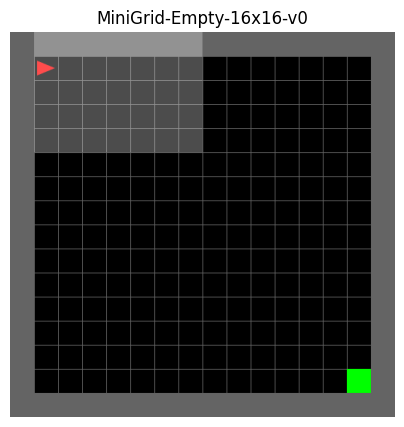

In [ ]:
# TODO
# Créer une version avec render_mode="rgb_array"
import matplotlib.pyplot as plt
env_mg_rgb = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env_mg_rgb.reset(seed=0)
frame = env_mg_rgb.render()
# Afficher une frame avec matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("MiniGrid-Empty-16x16-v0")
plt.show()
env_mg_rgb.close()


**Analyse :** qu’est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ? 

MiniGrid est plus difficile car :

- observation partielle (agent ne voit pas tout)
- représentation visuelle (image)
- navigation plus complexe

## 8. Politique aléatoire sur MiniGrid

In [26]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes
def random_minigrid_policy(obs, info, env):
    return env.action_space.sample()

def evaluate_minigrid_policy(policy_fn, n_episodes=20, seed_offset=0):
    env = gym.make("MiniGrid-Empty-16x16-v0")
    results_minigrid = []
    for episode in range(n_episodes):
        obs, info = env.reset(seed=seed_offset + episode)
        episode_reward = 0.0
        step_count = 0
        terminated = False
        truncated = False
        while not (terminated or truncated):
            action = policy_fn(obs, info, env)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            step_count += 1
        results_minigrid.append({
            "episode": episode,
            "steps": step_count,
            "reward": episode_reward,
            "cause": "terminated" if terminated else "truncated",
            "success": 1 if terminated and episode_reward > 0 else 0
        })
    env.close()
    return results_minigrid

results_minigrid_random = evaluate_minigrid_policy(random_minigrid_policy, n_episodes=20)
for r in results_minigrid_random:
    print(f"Épisode {r['episode']} - Étapes: {r['steps']}, "
          f"Récompense: {r['reward']:.3f}, Cause: {r['cause']}")

print("\nIndicateurs MiniGrid aléatoire")
print("Récompense moyenne :", np.mean([r["reward"] for r in results_minigrid_random]))
print("Longueur moyenne   :", np.mean([r["steps"] for r in results_minigrid_random]))
print("Taux de succès     :", np.mean([r["success"] for r in results_minigrid_random]))

Épisode 0 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 1 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 2 - Étapes: 285, Récompense: 0.750, Cause: terminated
Épisode 3 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 4 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 5 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 6 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 7 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 8 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 9 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 10 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 11 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 12 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 13 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 14 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Épisode 15 - Étapes: 1024, Récompense: 0.000, Cause: truncated
Ép

## 9. Politique réflexe minimale sur MiniGrid

In [27]:
# TODO
# Implémenter une politique à règles locales simples
# Actions MiniGrid usuelles : 0=left, 1=right, 2=forward, 3=pickup, 4=drop, 5=toggle, 6=done
def _turn_action(current_dir, target_dir):
    diff = (target_dir - current_dir) % 4
    if diff == 0:
        return 2  # forward
    elif diff == 1:
        return 1  # right
    elif diff == 3:
        return 0  # left
    else:
        return 1  # demi-tour: on commence par tourner à droite

def reflex_minigrid_policy(obs, info, env):
    agent_x, agent_y = map(int, env.unwrapped.agent_pos)
    goal_x = env.unwrapped.width - 2
    goal_y = env.unwrapped.height - 2

    if (agent_x, agent_y) == (goal_x, goal_y):
        return 6  # done
    if agent_x < goal_x:
        target_dir = 0  # right
    elif agent_y < goal_y:
        target_dir = 1  # down
    elif agent_x > goal_x:
        target_dir = 2  # left
    else:
        target_dir = 3  # up
    return _turn_action(env.unwrapped.agent_dir, target_dir)


In [28]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
results_minigrid_reflex = evaluate_minigrid_policy(reflex_minigrid_policy, n_episodes=20)

for r in results_minigrid_reflex:
    print(f"Épisode {r['episode']} - Étapes: {r['steps']}, "
          f"Récompense: {r['reward']:.3f}, Cause: {r['cause']}")

print("\n Comparaison MiniGrid : aléatoire vs réflexe ")
print("Reward moyenne aléatoire :", np.mean([r["reward"] for r in results_minigrid_random]))
print("Reward moyenne réflexe   :", np.mean([r["reward"] for r in results_minigrid_reflex]))
print("Longueur moyenne aléatoire :", np.mean([r["steps"] for r in results_minigrid_random]))
print("Longueur moyenne réflexe   :", np.mean([r["steps"] for r in results_minigrid_reflex]))
print("Succès aléatoire :", np.mean([r["success"] for r in results_minigrid_random]))
print("Succès réflexe   :", np.mean([r["success"] for r in results_minigrid_reflex]))


Épisode 0 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 1 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 2 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 3 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 4 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 5 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 6 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 7 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 8 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 9 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 10 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 11 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 12 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 13 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 14 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 15 - Étapes: 27, Récompense: 0.976, Cause: terminated
Épisode 16 - Étape

**Analyse :** pourquoi cette politique peut-elle tourner en rond ? 

Cette politique peut tourner en rond car elle ne possède aucune mémoire pour se souvenir des positions déjà visitées, et elle ne suit aucune stratégie globale pour atteindre un objectif. Elle applique toujours la même action sans s’adapter à l’environnement.

## 10. Politique d’exploration avec mémoire minimale

In [29]:
# TODO
# Implémenter une classe ou une fonction de politique avec mémoire légère
class MemoryMiniGridPolicy:
    def __init__(self):
        self.visits = {}
    def reset(self):
        self.visits = {}
    def __call__(self, obs, info, env):
        x, y = map(int, env.unwrapped.agent_pos)
        current_dir = int(env.unwrapped.agent_dir)
        goal = (env.unwrapped.width - 2, env.unwrapped.height - 2)
        if (x, y) == goal:
            return 6  # done
        self.visits[(x, y)] = self.visits.get((x, y), 0) + 1
        candidates = []
        for action_dir, (nx, ny) in {
            0: (x + 1, y),  # right
            1: (x, y + 1),  # down
            2: (x - 1, y),  # left
            3: (x, y - 1),  # up
        }.items():
            # rester à l'intérieur de la zone utile
            if 1 <= nx <= env.unwrapped.width - 2 and 1 <= ny <= env.unwrapped.height - 2:
                manhattan = abs(goal[0] - nx) + abs(goal[1] - ny)
                revisit_penalty = self.visits.get((nx, ny), 0)
                score = manhattan + 2 * revisit_penalty
                candidates.append((score, action_dir, (nx, ny)))

        candidates.sort(key=lambda x: x[0])
        target_dir = candidates[0][1]

        diff = (target_dir - current_dir) % 4
        if diff == 0:
            return 2  # forward
        elif diff == 1:
            return 1  # right
        elif diff == 3:
            return 0  # left
        else:
            # demi-tour : alterner pour éviter de bloquer
            return 0 if self.visits[(x, y)] % 2 == 0 else 1


In [30]:
# TODO
# Évaluer cette politique et comparer les résultats
def evaluate_minigrid_policy_with_memory(policy_obj, n_episodes=20, seed_offset=100):
    env = gym.make("MiniGrid-Empty-16x16-v0")
    results_memory = []

    for episode in range(n_episodes):
        policy_obj.reset()
        obs, info = env.reset(seed=seed_offset + episode)
        episode_reward = 0.0
        step_count = 0
        terminated = False
        truncated = False

        while not (terminated or truncated):
            action = policy_obj(obs, info, env)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            step_count += 1

        results_memory.append({
            "episode": episode,
            "steps": step_count,
            "reward": episode_reward,
            "cause": "terminated" if terminated else "truncated",
            "success": 1 if terminated and episode_reward > 0 else 0
        })

    env.close()
    return results_memory

memory_policy = MemoryMiniGridPolicy()
results_minigrid_memory = evaluate_minigrid_policy_with_memory(memory_policy, n_episodes=20)

print(" Comparaison MiniGrid : 3 politiques ")
print("Reward moyenne aléatoire :", np.mean([r["reward"] for r in results_minigrid_random]))
print("Reward moyenne réflexe   :", np.mean([r["reward"] for r in results_minigrid_reflex]))
print("Reward moyenne mémoire   :", np.mean([r["reward"] for r in results_minigrid_memory]))

print("Longueur moyenne aléatoire :", np.mean([r["steps"] for r in results_minigrid_random]))
print("Longueur moyenne réflexe   :", np.mean([r["steps"] for r in results_minigrid_reflex]))
print("Longueur moyenne mémoire   :", np.mean([r["steps"] for r in results_minigrid_memory]))

print("Succès aléatoire :", np.mean([r["success"] for r in results_minigrid_random]))
print("Succès réflexe   :", np.mean([r["success"] for r in results_minigrid_reflex]))
print("Succès mémoire   :", np.mean([r["success"] for r in results_minigrid_memory]))

 Comparaison MiniGrid : 3 politiques 
Reward moyenne aléatoire : 0.0859716796875
Reward moyenne réflexe   : 0.9762695312500002
Reward moyenne mémoire   : 0.9762695312500002
Longueur moyenne aléatoire : 943.25
Longueur moyenne réflexe   : 27.0
Longueur moyenne mémoire   : 27.0
Succès aléatoire : 0.15
Succès réflexe   : 1.0
Succès mémoire   : 1.0


## 11. Wrapper utile : RecordEpisodeStatistics

In [31]:
# TODO
from gymnasium.wrappers import RecordEpisodeStatistics
# Appliquer le wrapper à l'un des environnements et observer info["episode"]
env_stats = gym.make("Taxi-v3")
env_stats = RecordEpisodeStatistics(env_stats)

obs, info = env_stats.reset(seed=0)
terminated = False
truncated = False

while not (terminated or truncated):
    action = env_stats.action_space.sample()
    obs, reward, terminated, truncated, info = env_stats.step(action)

print("Cause de fin :", "terminated" if terminated else "truncated")
print('Contenu de info["episode"] :', info.get("episode", "absent"))

env_stats.close()



Cause de fin : truncated
Contenu de info["episode"] : {'r': -713.0, 'l': 200, 't': 0.007387}


## 12. Comparaison finale

In [32]:
# TODO
# Construire un tableau récapitulatif de toutes les politiques testées
final_summary = pd.DataFrame([
    {
        "Environnement": "Taxi-v3",
        "Politique": "Aléatoire",
        "Reward moyenne": np.mean([r["reward"] for r in results]),
        "Longueur moyenne": np.mean([r["steps"] for r in results]),
        "Succès": np.mean([1 if r["cause"] == "terminated" else 0 for r in results]),
    },
    {
        "Environnement": "Taxi-v3",
        "Politique": "Aléatoire contrainte",
        "Reward moyenne": np.mean([r["reward"] for r in results_constrained]),
        "Longueur moyenne": np.mean([r["steps"] for r in results_constrained]),
        "Succès": np.mean([1 if r["cause"] == "terminated" else 0 for r in results_constrained]),
    },
    {
        "Environnement": "Taxi-v3",
        "Politique": "Heuristique simple",
        "Reward moyenne": np.mean([r["reward"] for r in results_heuristic]),
        "Longueur moyenne": np.mean([r["steps"] for r in results_heuristic]),
        "Succès": np.mean([1 if r["cause"] == "terminated" else 0 for r in results_heuristic]),
    },
    {
        "Environnement": "MiniGrid-Empty-16x16-v0",
        "Politique": "Aléatoire",
        "Reward moyenne": np.mean([r["reward"] for r in results_minigrid_random]),
        "Longueur moyenne": np.mean([r["steps"] for r in results_minigrid_random]),
        "Succès": np.mean([r["success"] for r in results_minigrid_random]),
    },
    {
        "Environnement": "MiniGrid-Empty-16x16-v0",
        "Politique": "Réflexe minimale",
        "Reward moyenne": np.mean([r["reward"] for r in results_minigrid_reflex]),
        "Longueur moyenne": np.mean([r["steps"] for r in results_minigrid_reflex]),
        "Succès": np.mean([r["success"] for r in results_minigrid_reflex]),
    },
    {
        "Environnement": "MiniGrid-Empty-16x16-v0",
        "Politique": "Mémoire légère",
        "Reward moyenne": np.mean([r["reward"] for r in results_minigrid_memory]),
        "Longueur moyenne": np.mean([r["steps"] for r in results_minigrid_memory]),
        "Succès": np.mean([r["success"] for r in results_minigrid_memory]),
    },
])

final_summary

,Environnement,Politique,Reward moyenne,Longueur moyenne,Succès
0,Taxi-v3,Aléatoire,-736.550000,192.35,0.10
1,Taxi-v3,Aléatoire contrainte,-191.900000,192.95,0.05
2,Taxi-v3,Heuristique simple,-147.050000,152.30,0.25
3,MiniGrid-Empty-16x16-v0,Aléatoire,0.085972,943.25,0.15
4,MiniGrid-Empty-16x16-v0,Réflexe minimale,0.976270,27.00,1.00
5,MiniGrid-Empty-16x16-v0,Mémoire légère,0.976270,27.00,1.00


### Réponses de synthèse

### 1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?

L’environnement Taxi-v3 est le plus facile pour concevoir une politique explicite. En effet, il est entièrement observable et possède un espace d’états discret et limité. Les règles sont simples et déterministes, ce qui permet de définir facilement des stratégies basées sur des conditions logiques (ex : aller vers le passager puis vers la destination).

### 2. Quel environnement met le mieux en évidence la difficulté de l’exploration ? Pourquoi ?

L’environnement MiniGrid Contrairement à Taxi-v3, car il est partiellement observable et plus complexe. L’agent ne voit qu’une partie de l’environnement, ce qui rend la prise de décision plus difficile. De plus, la présence d’obstacles et la nécessité d’explorer efficacement l’espace rendent les politiques simples inefficaces.

### 3. Quelles sont les limites principales des politiques codées à la main ?

Les politiques codées à la main présentent plusieurs limites importantes. Elles manquent de flexibilité et ne s’adaptent pas à des environnements complexes ou dynamiques. Elles nécessitent une connaissance préalable de l’environnement et elles ne permettent pas de apprendre de nouvelles stratégies.

### 4. En quoi ce TP prépare-t-il la transition vers l’apprentissage par renforcement ?

Ce TP prépare à l’apprentissage par renforcement en montrant les limites des approches manuelles. Il met en évidence la nécessité de méthodes capables d’apprendre automatiquement à partir des interactions avec l’environnement. Le Reinforcement Learning permet justement à un agent d’améliorer sa politique en fonction des récompenses reçues, sans avoir à coder explicitement toutes les règles.

## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [33]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    env = gym.make(env_id, render_mode="rgb_array")

    # TODO
    # 1. reset l'environnement
    # 2. exécuter l'épisode
    # 3. appeler env.render() pour récupérer les images
    # 4. stocker plusieurs frames dans une liste
    # 5. fermer l'environnement
    # 6. retourner la liste des frames

    frames = []

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return frames


### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [34]:
def show_selected_frames(frames):
    # TODO
    # Afficher 3 images représentatives de l'épisode
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]
    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [35]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

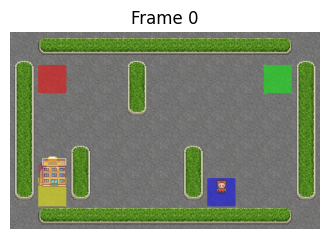

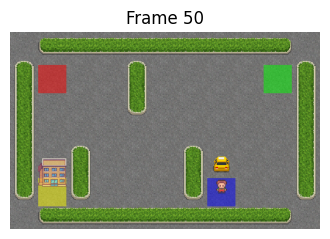

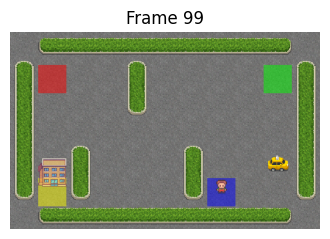

In [36]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [39]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    # TODO
    # 1. lancer un épisode
    # 2. exécuter la politique jusqu'à la fin
    # 3. fermer proprement l'environnement
    # 4. retourner le chemin du dossier contenant la vidéo

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [40]:
!pip install "gymnasium[other]"

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------- ----------------- 3.9/7.0 MB 19.5 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 21.5 MB/s  0:00:00
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ----------- ---------------------------- 8.9/31.2 MB 46.3 MB/s eta 0:00:01
   ----------- ---------------------------- 8.9/31.2 MB 46.3 MB/s eta 0:00:01
   ----------- ---------------------------- 9.2/31.2 MB 13.9 MB/s eta 0:00:02
   ----------- ---------------------------- 9.2/31.2 MB 13.9 MB/s eta 0:00:02
   ------------ --------------------------- 9.4/31.2 MB 9.6 MB/s eta 0:00:03
   ------------ --------------------------- 10.0/31.2 MB 7.9 MB/s eta 0:00:03
   -------------- ------------------------- 11.3/31.2 MB 7.6 MB/s eta 0:00:03
   --------------- -

  You can safely remove it manually.

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\hp\OneDrive - um5.ac.ma\Bureau\Jeu-Vid\jeuxvideosia-tp1-tamhid\videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


WindowsPath('videos_minigrid_random')

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.




- La politique aléatoire présente une trajectoire désorganisée. L’agent se déplace sans stratégie, effectue des actions inutiles et met généralement un grand nombre d’étapes pour atteindre l’objectif.

- La politique heuristique peut bloquer dans Taxi-v3 car elle choisit une direction uniquement à partir de la position du taxi et de l’objectif, sans tenir compte des murs internes de l’environnement. Ainsi, si le taxi essaie de se déplacer dans une direction bloquée, il répète la même action sans progresser, ce qui donne l’impression qu’il reste immobile.

- La politique réflexe sur MiniGrid, bien qu’elle tente de se diriger vers l’objectif, reste limitée. En présence d’obstacles, l’agent peut se bloquer ou tourner en rond car il ne possède ni mémoire ni stratégie d’exploration efficace.



In [43]:
# TODO
# Produire ici 2 ou 3 vidéos pour comparer les politiques sur Taxi ou MiniGrid.

def taxi_random_video_policy(obs, info, env, step_idx):
    return env.action_space.sample()

def taxi_heuristic_video_policy(obs, info, env, step_idx):
    return heuristic_taxi_policy(obs, env)

def minigrid_reflex_video_policy(obs, info, env, step_idx):
    return reflex_minigrid_policy(obs, info, env)

video_taxi_random = record_policy_video(
    env_id="Taxi-v3",
    policy_fn=taxi_random_video_policy,
    video_folder="videos_taxi_random",
    seed=0,
    max_steps=120,
    episode_name="taxi_random"
)

video_taxi_heuristic = record_policy_video(
    env_id="Taxi-v3",
    policy_fn=taxi_heuristic_video_policy,
    video_folder="videos_taxi_heuristic",
    seed=0,
    max_steps=120,
    episode_name="taxi_heuristic"
)

video_minigrid_reflex = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=minigrid_reflex_video_policy,
    video_folder="videos_minigrid_reflex",
    seed=0,
    max_steps=150,
    episode_name="minigrid_reflex"
)

# Exemple attendu :
# record_policy_video(... politique aléatoire ...)
# record_policy_video(... politique heuristique ...)
# record_policy_video(... politique avec mémoire ...)

### Questions d'analyse visuelle

1. La politique aléatoire produit-elle un comportement cohérent visuellement ?

La politique aléatoire ne produit pas un comportement cohérent. L’agent effectue des actions sans logique apparente, ce qui donne une trajectoire désorganisée avec de nombreux déplacements inutiles.

2. Quelle politique semble la plus efficace à l'observation ?

La politique avec mémoire semble être la plus efficace. Contrairement aux autres politiques, elle évite de revisiter les mêmes positions, ce qui réduit les répétitions et améliore l’exploration de l’environnement. Elle présente un comportement plus fluide et plus cohérent, ce qui lui permet d’atteindre l’objectif plus efficacement que la politique aléatoire et la politique heuristique.

3. Voyez-vous des hésitations, répétitions ou blocages ?

Oui, on observe des répétitions et des blocages. La politique aléatoire effectue de nombreuses actions inutiles. De plus, la politique heuristique peut rester bloquée lorsqu’elle tente de se déplacer dans une direction empêchée par un mur, ce qui entraîne une répétition de la même action sans progression.

4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?

Oui, les observations visuelles confirment les métriques. La politique aléatoire correspond à un grand nombre d’étapes et une faible efficacité, tandis que la politique heuristique montre un comportement plus structuré, bien que parfois bloqué. Cela reflète les performances mesurées précédemment.

5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?

MiniGrid est plus informatif visuellement car il permet d’observer clairement les déplacements de l’agent dans un environnement plus complexe avec obstacles. Contrairement à Taxi-v3, où les mouvements peuvent être moins intuitifs à cause des murs internes invisibles, MiniGrid rend plus évidente la difficulté de navigation et d’exploration.


### Extension facultative

Créer un tableau comparatif du type :

| Environnement | Politique           | Reward moyenne | Succès | Observation visuelle |
|--------------|-------------------|----------------|--------|----------------------|
| Taxi-v3      | Aléatoire         | Faible         | Faible | Déplacements désorganisés, nombreuses actions inutiles |
| Taxi-v3      | Heuristique       | Moyenne        | Variable | Comportement structuré mais blocages fréquents à cause des murs |
| MiniGrid     | Aléatoire         | Faible         | Très faible | Mouvement aléatoire, exploration inefficace |
| MiniGrid     | Mémoire minimale  | Meilleure      | Moyen à bon | Exploration plus efficace, moins de répétitions, comportement plus fluide |

Cela vous aidera à relier **analyse quantitative** et **analyse visuelle**.
